In [21]:
# Setup and Imports
# This cell imports all the necessary libraries for data manipulation, machine learning modeling, and evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [22]:
# Load Data
# This cell loads the `customer_segments.csv` dataset into a pandas DataFrame and displays its shape and the first few rows.
df = pd.read_csv("/content/customer_segments.csv")

print(df.shape)
df.head()

(44787, 25)


,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency,cluster
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667,0
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667,0
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667,0
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667,0
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667,0


In [23]:
# Define High-Value Customers
# Here, a threshold for 'monetary_value' is calculated (75th percentile), and a new binary column `high_value_customer` is created to identify customers above this threshold.
threshold = df[
    "monetary_value"
].quantile(0.75)

print(
    "High Value Threshold:",
    threshold
)

df["high_value_customer"] = (
    df["monetary_value"]
    > threshold
).astype(int)

High Value Threshold: 159.0


In [24]:
# High-Value Customer Distribution
# This cell shows the count and normalized percentage of high-value customers in the dataset.
print(
    df["high_value_customer"]
    .value_counts()
)

print()

print(
    df["high_value_customer"]
    .value_counts(normalize=True)
    * 100
)

high_value_customer
0    33658
1    11129
Name: count, dtype: int64

high_value_customer
0    75.151272
1    24.848728
Name: proportion, dtype: float64


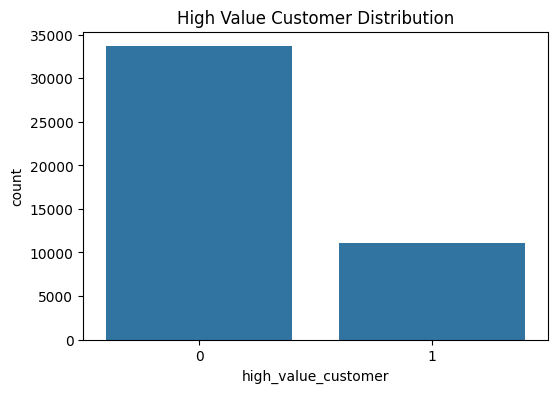

In [25]:
# Visualize High-Value Customer Distribution
# This cell generates a count plot to visualize the distribution of high-value customers.
plt.figure(figsize=(6,4))

sns.countplot(
    x="high_value_customer",
    data=df
)

plt.title(
    "High Value Customer Distribution"
)

plt.show()

In [26]:
# Define Columns to Drop
# This cell initializes a list of columns that will be excluded from the feature set, specifically `customer_unique_id`.
drop_cols = [
    "customer_unique_id"
]

In [27]:
# Prepare Features (X) and Target (y)
# This cell separates the features (X) from the target variable (y), which is `high_value_customer`.
X = df.drop(
    columns=
    drop_cols +
    ["high_value_customer"],
    errors="ignore"
)

y = df["high_value_customer"]

In [28]:
# One-Hot Encode Categorical Features
# This cell applies one-hot encoding to the `customer_state` categorical feature to convert it into a numerical format suitable for machine learning models.
X = pd.get_dummies(
    X,
    columns=["customer_state"],
    drop_first=True
)

In [29]:
# Split Data into Training and Test Sets
# This cell divides the dataset into training and testing sets, ensuring a stratified split to maintain the proportion of high-value customers in both sets.
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

In [30]:
# Impute Missing Values
# This cell uses `SimpleImputer` with a 'median' strategy to handle any missing values in the feature sets.
imputer = SimpleImputer(
    strategy="median"
)

X_train = imputer.fit_transform(
    X_train
)

X_test = imputer.transform(
    X_test
)

In [31]:
# Scale Features
# This cell uses `StandardScaler` to standardize the features, which helps improve the performance of many machine learning algorithms.
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [32]:
# Define Model Evaluation Function
# This cell defines a utility function `evaluate_model` to calculate and print various classification metrics (Accuracy, Precision, Recall, F1, ROC AUC) for a given model.
def evaluate_model(
    name,
    model,
    X_test,
    y_test
):

    preds = model.predict(
        X_test
    )

    probs = model.predict_proba(
        X_test
    )[:,1]

    print(
        f"\n{name}"
    )

    print("="*50)

    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_test,
                preds
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_test,
                preds
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_test,
                preds
            ),
            4
        )
    )

    print(
        "F1:",
        round(
            f1_score(
                y_test,
                preds
            ),
            4
        )
    )

    print(
        "ROC AUC:",
        round(
            roc_auc_score(
                y_test,
                probs
            ),
            4
        )
    )

    return {
        "Model": name,
        "Accuracy":
        accuracy_score(
            y_test,
            preds
        ),
        "Precision":
        precision_score(
            y_test,
            preds
        ),
        "Recall":
        recall_score(
            y_test,
            preds
        ),
        "F1":
        f1_score(
            y_test,
            preds
        ),
        "ROC_AUC":
        roc_auc_score(
            y_test,
            probs
        )
    }

In [33]:
# Train and Evaluate Logistic Regression Model
# This cell initializes, trains, and evaluates a Logistic Regression model using the `evaluate_model` function.
log_model = LogisticRegression(
    max_iter=3000
)

log_model.fit(
    X_train,
    y_train
)

log_results = evaluate_model(
    "Logistic Regression",
    log_model,
    X_test,
    y_test
)


Logistic Regression
Accuracy: 0.9934
Precision: 0.9941
Recall: 0.9793
F1: 0.9866
ROC AUC: 0.9999


In [34]:
# Train and Evaluate Random Forest Model
# This cell initializes, trains, and evaluates a Random Forest Classifier model.
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)


Random Forest
Accuracy: 0.9999
Precision: 1.0
Recall: 0.9996
F1: 0.9998
ROC AUC: 1.0


In [35]:
# Train and Evaluate XGBoost Model
# This cell initializes, trains, and evaluates an XGBoost Classifier model.
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)


XGBoost
Accuracy: 0.9997
Precision: 1.0
Recall: 0.9987
F1: 0.9993
ROC AUC: 1.0


In [36]:
# Compare Model Performance
# This cell consolidates the evaluation results from all trained models into a DataFrame and sorts them by ROC AUC score for easy comparison.
results = pd.DataFrame([
    log_results,
    rf_results,
    xgb_results
])

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.999888,1.000000,0.999551,0.999775,1.000000
2,XGBoost,0.999665,1.000000,0.998652,0.999326,0.999997
0,Logistic Regression,0.993414,0.994072,0.979335,0.986649,0.999855


In [37]:
# Calculate Feature Importance
# This cell calculates and sorts the feature importances from the XGBoost model to understand which features are most predictive.
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    xgb_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

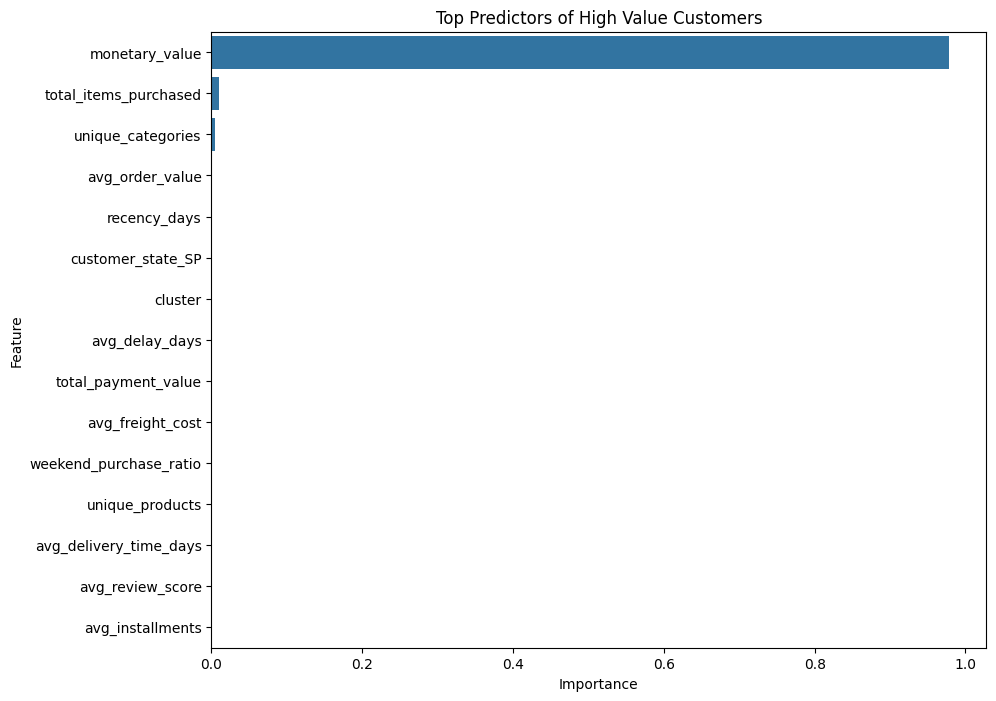

In [38]:
# Visualize Top Predictors
# This cell generates a bar plot to visualize the top 15 most important features identified by the XGBoost model.
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictors of High Value Customers"
)

plt.show()

In [39]:
# Save Models and Transformers
# This cell uses `joblib` to save the trained XGBoost model, the StandardScaler, and the SimpleImputer for future use.
joblib.dump(
    xgb_model,
    "high_value_customer_model.pkl"
)

joblib.dump(
    scaler,
    "high_value_customer_scaler.pkl"
)

joblib.dump(
    imputer,
    "high_value_customer_imputer.pkl"
)

['high_value_customer_imputer.pkl']

In [40]:
# Save Model Results
# This cell saves the DataFrame containing the model evaluation results to a CSV file.
results.to_csv(
    "high_value_customer_results.csv",
    index=False
)